In [ ]:
import torch
import torch.nn

# 1. パッチ埋め込み（PatchEmbedding）
class PatchEmbedding(torch.nn.Module):
    def __init__(self, img_size, patch_size, in_chans, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        # nn.Conv2d でパッチ分割＋線形埋め込み
        self.proj = torch.nn.Conv2d(
            in_chans, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
        # クラス埋め込みトークンと位置埋め込み
        num_patches = (img_size // patch_size) ** 2
        self.cls_token = torch.nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = torch.nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.size(0)
        # [1] 畳み込みによるパッチ分割＋線形変換
        # x: [B, C, H, W]
        x = self.proj(x)
        # → [B, embed_dim, H/patch_size, W/patch_size]
        
        # [2] パッチ次元をまとめて一次元にフラット化
        # flatten(2) は軸2以降をすべてまとめる
        x = x.flatten(2)
        # → [B, embed_dim, num_patches]
        
        # [3] パッチ次元を最後に移動して系列に
        x = x.transpose(1, 2)
        # → [B, num_patches, embed_dim]
        
        # [4] CLSトークンを各バッチに複製して先頭に追加
        # self.cls_token: [1, 1, embed_dim]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # → [B, 1, embed_dim]
        x = torch.cat([cls_tokens, x], dim=1)
        # → [B, 1 + num_patches, embed_dim]
        
        # [5] 位置埋め込みを加算
        # self.pos_embed: [1, 1 + num_patches, embed_dim]
        x = x + self.pos_embed
        # → [B, 1 + num_patches, embed_dim]
        
        return x

class MultiHeadSelfAttention(torch.nn.Module):
    def __init__(self, embed_dim, num_heads, attn_dropout=0.0, proj_dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        # QKV を同時に計算
        self.qkv = torch.nn.Linear(embed_dim, embed_dim * 3)
        self.attn_dropout = torch.nn.Dropout(attn_dropout)
        self.proj = torch.nn.Linear(embed_dim, embed_dim)
        self.proj_dropout = torch.nn.Dropout(proj_dropout)

    def forward(self, x):
        B, N, C = x.shape  # バッチ, トークン数, 埋め込み次元
        # [B, N, 3C]
        qkv = self.qkv(x)
        # 3つに分割してリシェイプ: [B, N, 3, heads, head_dim]
        qkv = qkv.view(B, N, 3, self.num_heads, self.head_dim)
        # 軸を並べ替えて： [3, B, heads, N, head_dim]
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # 各 [B, heads, N, head_dim]

        # Attention スコアの計算
        attn = (q @ k.transpose(-2, -1)) * self.scale  # [B, heads, N, N]
        attn = attn.softmax(dim=-1)
        attn = self.attn_dropout(attn)

        # Attention を Value に適用
        out = attn @ v  # [B, heads, N, head_dim]
        # 頭方向とトークン数を統合
        out = out.transpose(1, 2).reshape(B, N, C)  # [B, N, C]
        out = self.proj(out)
        out = self.proj_dropout(out)
        return out

class MLP(torch.nn.Module):
    def __init__(self, embed_dim, mlp_ratio, dropout=0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = torch.nn.Linear(embed_dim, hidden_dim)
        self.act = torch.nn.GELU()
        self.fc2 = torch.nn.Linear(hidden_dim, embed_dim)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

class EncoderBlock(torch.nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio, qkv_bias=True,
                 attn_dropout=0.0, proj_dropout=0.0, drop_path=0.0):
        super().__init__()
        self.norm1 = torch.nn.LayerNorm(embed_dim, eps=1e-6)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, attn_dropout, proj_dropout)
        self.norm2 = torch.nn.LayerNorm(embed_dim, eps=1e-6)
        self.mlp = MLP(embed_dim, mlp_ratio, proj_dropout)
        # DropPath（ランダムにショートカットを切る）を使う場合
        self.drop_path = torch.nn.Identity() if drop_path == 0.0 else \
                         torch.nn.Dropout(drop_path)

    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

class ViT(torch.nn.Module):
    def __init__(
            self,
            img_size=32,   # 画像の縦の長さ（= 横の長さ）
            patch_size=4,  # パッチの縦の長さ（= 横の長さ）
            in_chans=3,    # 入力チャネル数（例: RGB画像なら3）
            embed_dim=128, # パッチ埋め込み後の特徴量の次元数
            depth=6,       # Transformerエンコーダブロックの数
            num_heads=8,   # マルチヘッド自己注意のヘッド数
            mlp_ratio=4.0, # MLP内隠れ層の次元が embed_dim の何倍か
            num_classes=10 # 分類するクラスの数
    ):
        super().__init__()

        # パッチ埋め込み
        self.patch_embed = PatchEmbedding(
            img_size,
            patch_size,
            in_chans,
            embed_dim,
        )

        # エンコーダブロックをdepth個分並べる
        self.blocks = torch.nn.ModuleList([
            EncoderBlock(
                embed_dim, num_heads, mlp_ratio,
                qkv_bias=True, attn_dropout=0.0,
                proj_dropout=0.0, drop_path=0.0
            )
            for _ in range(depth)
        ])

        self.norm = torch.nn.LayerNorm(embed_dim, eps=1e-6)

        self.head = torch.nn.Linear(embed_dim, num_classes)


    def forward(self, x):

        x = self.patch_embed(x)

        for blk in self.blocks:
            x = blk(x)
        
        x = self.norm(x)

        cls_token_final = x[:, 0]
        logits = self.head(cls_token_final)

        return logits



In [35]:
model = ViT(
    img_size=32, patch_size=4, in_chans=3,
    embed_dim=128, depth=6, num_heads=8,
    mlp_ratio=4.0, num_classes=10
)
dummy = torch.randn(2, 3, 32, 32)
out = model(dummy)
print(out)  # torch.Size([2, 10])

tensor([[-0.6985, -0.8419,  0.7949,  0.7883, -0.6205,  0.0359, -0.9111,  1.2845,
         -0.3232,  0.0577],
        [-0.6191, -0.0140,  0.9860,  1.1545, -0.9849,  0.0258, -0.8889,  1.2715,
         -0.4100,  0.2364]], grad_fn=<AddmmBackward0>)


### 学習

In [36]:
import torchvision

# デバイス設定（GPU があれば GPU、なければ CPU を使用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. データ準備：変換（transforms）と DataLoader（データローダー）
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),                    # テンソル化
    torchvision.transforms.Normalize((0.5,)*3, (0.5,)*3)  # 正規化（平均, 標準偏差）
])

trainset = torchvision.datasets.CIFAR10(
    root='./data/CIFAR10', train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True      # バッチサイズ64, シャッフル有効
)

testset = torchvision.datasets.CIFAR10(
    root='./data/CIFAR10', train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False     # テストはシャッフル不要
)

# 2. モデル・損失関数・最適化手法の定義
model = ViT(                                  # ViT（ビジョントランスフォーマー）
    img_size=32, patch_size=4, in_chans=3,
    embed_dim=128, depth=6, num_heads=8,
    mlp_ratio=4.0, num_classes=10
).to(device)

criterion = torch.nn.CrossEntropyLoss()             # 交差エントロピー損失
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Adam（アダム）最適化

# 3. 学習ループ
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()                 # 勾配の初期化
        outputs = model(images)               # 順伝播
        loss = criterion(outputs, labels)     # 損失計算
        loss.backward()                       # 逆伝播
        optimizer.step()                      # パラメータ更新
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{num_epochs}  Loss: {running_loss/len(trainloader):.4f}")


Files already downloaded and verified
Files already downloaded and verified
Epoch 1/5  Loss: 1.6697
Epoch 2/5  Loss: 1.3261
Epoch 3/5  Loss: 1.2183
Epoch 4/5  Loss: 1.1536
Epoch 5/5  Loss: 1.0998


### 評価

In [37]:
# 4. テストデータでの評価
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  # 最もスコアの高いクラスを取得
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 57.78%


# テスト

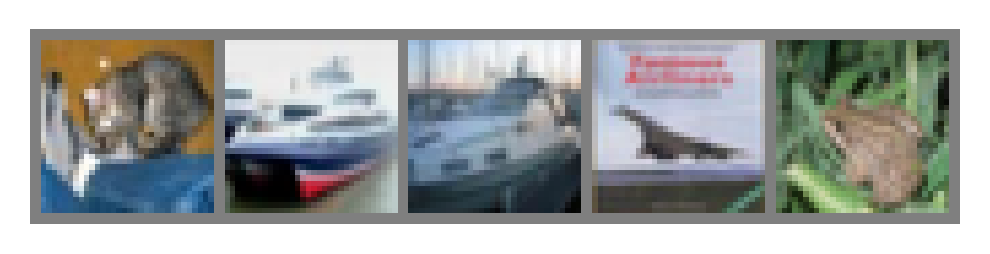

groundTruth:  [3, 8, 8, 0, 6]
predict:      [5, 8, 0, 8, 6]


In [57]:
# 7. Notebook上でサンプル画像を表示する関数定義
import numpy as np
import matplotlib.pyplot as plt                  # matplotlib（マットプロットリブ）

def imshow(img):
    img = img / 2 + 0.5             # 正規化を戻す
    npimg = img.numpy()
    plt.figure(figsize=(4,4), dpi=300)
    plt.axis('off')
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


sampleloader = torch.utils.data.DataLoader(
    testset, batch_size=5, shuffle=False     # テストはシャッフル不要
)

# ミニバッチを取得
dataiter = iter(sampleloader)
images, labels = next(dataiter)

# 予測
model.eval()
with torch.no_grad():
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)  # 最もスコアの高いクラスを取得

# 画像をグリッド表示
imshow(torchvision.utils.make_grid(images.to("cpu")))

# ラベル表示
print('groundTruth: ', labels.tolist())
print('predict:     ', predicted.tolist())

